In [6]:
import cv2
import matplotlib.pyplot as plt
import matplotlib
from random import random
from model import DINOCell
from pipeline import get_pipeline
from PIL import Image
import torch
import numpy as np
import os
import sys
from utils import convert_label_to_rainbow

# Load Model

In [ ]:
# Load the model
print('loading model...')
model = DINOCell(
    dino_model=None, 
    decoder_type="upsample", 
    objective_type="flows", 
    use_dino_weights=False, 
    patch_size=8, #change, 8
    feat_size=64, 
    crop_size=512, 
    drop_rate=0.05, 
    dropout_in_encoder=True, 
    finetune_vision=True, 
    finetune_decoder=True, 
    finetune_prediction_head=True
)

model_save_path = '../models/DINOCell_demo_model.pt'
model.load_state_dict(torch.load(model_save_path, map_location=torch.device('cpu')))

#device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

#pipeline setup
pipeline = get_pipeline("flows", model, device, crop_size=512, use_advanced_augmentations=False, overlap_size=512//4)

loading model...


RuntimeError: Error(s) in loading state_dict for DINOCell:
	Missing key(s) in state_dict: "encoder.vision_neck.0.weight", "encoder.vision_neck.1.weight", "encoder.vision_neck.1.bias", "encoder.vision_neck.2.weight", "encoder.vision_neck.3.weight", "encoder.vision_neck.3.bias", "decoder.decoder.decoder.2.0.weight", "decoder.decoder.decoder.2.0.bias", "prediction_head.prediction_head.flows_dx_pred_head.3.weight", "prediction_head.prediction_head.flows_dx_pred_head.3.bias", "prediction_head.prediction_head.flows_dx_pred_head.5.weight", "prediction_head.prediction_head.flows_dx_pred_head.5.bias", "prediction_head.prediction_head.flows_dy_pred_head.3.weight", "prediction_head.prediction_head.flows_dy_pred_head.3.bias", "prediction_head.prediction_head.flows_dy_pred_head.5.weight", "prediction_head.prediction_head.flows_dy_pred_head.5.bias", "prediction_head.prediction_head.cell_prob_pred_head.3.weight", "prediction_head.prediction_head.cell_prob_pred_head.3.bias", "prediction_head.predictio

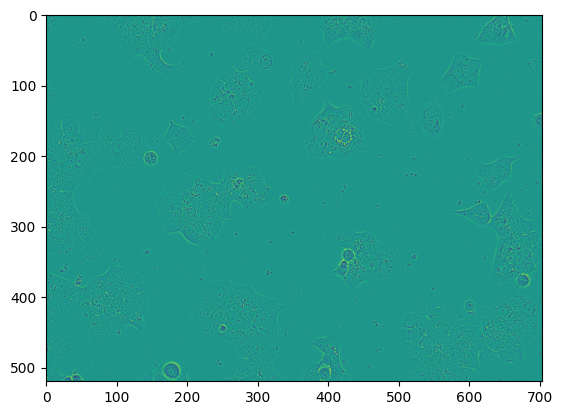

NameError: name 'pipeline' is not defined

In [ ]:
img_path = 'demo_images/LiveCell_test_image.png'
image = np.array(Image.open(img_path))

pred_labels, flows, img = pipeline.run(image, return_raw_preds=True)

#~~~~~~~~~~~~~~~~~~~~~~
#   VISUALIZATION
#~~~~~~~~~~~~~~~~~~~~~~

mask_preds_rgb = convert_label_to_rainbow(pred_labels)
mask_preds_rgb[pred_labels == 0] = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)[pred_labels == 0]


fig, ax = plt.subplots(1, 2, figsize=(10, 10))

#remove axes
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

#set 1 in borders
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].spines['left'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['bottom'].set_visible(False)
ax[1].spines['left'].set_visible(False)

ax[0].imshow(image, cmap='gray')
ax[1].imshow(image, cmap='gray')
ax[1].imshow(mask_preds_rgb, cmap='gray', alpha=0.7)

plt.show()